In [24]:
import ssl
import urllib.request

ssl._create_default_https_context = ssl._create_unverified_context

In [25]:
import pandas as pd
import numpy as np
import pickle
import re
import nltk
import string
import emoji
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.svm import SVC
# from thundersvm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from gensim.models import FastText

import fasttext
import fasttext.util

from argparse import Namespace


In [26]:
FINE_TUNED_DIR = '../pretained_or_finetune-models'
REVIEWS_DATASET_DIR = '../dataset/reviews'
UTILS_DIR = '../utils'
NLTK_DATA_PATH = f"{FINE_TUNED_DIR}/nltk_data"

nltk.data.path.append(NLTK_DATA_PATH)

In [27]:
args = Namespace(
    VECTOR_SIZE=300,
    SVM_KERNEL='rbf', # rbf, linear, poly
    VECTOR_MAX_FEATURES=10000,
    VECTOR_NGRAM_RANGE=(1, 2),
)

In [29]:
tourism_reviews_en = pd.read_parquet(f"{REVIEWS_DATASET_DIR}/TripAdvisor_reviews_EN.parquet")
tourism_reviews_en.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11528 entries, 0 to 11527
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   location_id     11528 non-null  int64 
 1   review_id       11528 non-null  int64 
 2   lang            11528 non-null  object
 3   published_date  11528 non-null  object
 4   rating          11528 non-null  int64 
 5   helpful_votes   11528 non-null  int64 
 6   url             11528 non-null  object
 7   review_text     11528 non-null  object
 8   review_title    11528 non-null  object
 9   trip_type       11496 non-null  object
 10  travel_date     11496 non-null  object
 11  username        11527 non-null  object
 12  user_location   8507 non-null   object
 13  avatar_url      11227 non-null  object
dtypes: int64(4), object(10)
memory usage: 1.2+ MB


In [30]:
columns_to_use = ['helpful_votes', 'location_id', 'review_id', 'review',
                  'review_subject', 'trip_type', 'rating',
                  'location_name', 'province', 'place_id', 'emotion', 'cleaned_review']
columns_to_train = ['review_id', 'location_id', 'review_text', 'rating']
review_df = tourism_reviews_en[columns_to_train]

In [31]:
review_df.describe()

,review_id,location_id,rating
count,1.152800e+04,1.152800e+04,11528.000000
mean,7.653254e+08,7.386930e+06,4.127516
std,1.898530e+08,5.523549e+06,1.126221
min,1.200876e+07,3.110380e+05,1.000000
25%,6.557496e+08,3.238087e+06,4.000000
50%,7.854387e+08,6.669341e+06,4.000000
75%,9.324026e+08,1.013695e+07,5.000000
max,9.945995e+08,2.779174e+07,5.000000


In [32]:
review_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11528 entries, 0 to 11527
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   review_id    11528 non-null  int64 
 1   location_id  11528 non-null  int64 
 2   review_text  11528 non-null  object
 3   rating       11528 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 360.4+ KB


In [33]:
review_df

,review_id,location_id,review_text,rating
0,989555402,456633,Nice museum that explained the opium trade in ...,5
1,980263758,456633,Good knowledge. The process from start and the...,5
2,963563510,456633,Very Intressant how and what surrounding the c...,3
3,947103623,456633,I didn't know much about the history of opium ...,5
4,947032475,456633,If you ever wanted to know anything about opiu...,5
...,...,...,...,...
11523,951001190,12881708,Nice small village between the mountain and th...,1
11524,709753934,12881708,Calm and relaxing feeling. A bunches of bungal...,5
11525,666206725,12881708,The beach and view point are absolutely pristi...,5
11526,639110666,12881708,It is a nice and realy peaceful beach on weekd...,4


In [34]:
from nltk.corpus import stopwords

custom_stopwords = set(stopwords.words('english')) 

In [35]:
from nltk.stem import WordNetLemmatizer

stop_words = custom_stopwords
lemmatizer = WordNetLemmatizer()

In [36]:
def advanced_clean_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)  # Remove numbers
    text = re.sub(r'[^a-z\s]', '', text)  # Remove special characters
    text = re.sub(r'\b(u|ur|b4)\b', 'you', text)  # Replace common abbreviations
    
    # Lowercasing
    text = text.lower()
    
    # Handling Emoji
    text = emoji.demojize(text)
    
    # Removing Punctuation
    text = ''.join([char for char in text if char not in string.punctuation])
    
    # Tokenization
    tokens = nltk.word_tokenize(text)
    
    # Removing Stop Words
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]

    # Lemmatization
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(token) for token in tokens]

    # Join tokens back to a single string
    return ' '.join(tokens)

In [37]:
# Apply preprocessing to the review texts
review_df['cleaned_review'] = review_df['review_text'].apply(advanced_clean_text)

# 2. สร้าง Word Embeddings ด้วย Word2Vec
# word2vec_model = Word2Vec(sentences=review_df['cleaned_review'], vector_size=300, window=5, min_count=1, sg=1)  # ใช้ Skip-Gram
# sentences = [row.split() for row in review_df['cleaned_review']]
# word2vec_model = Word2Vec(sentences, vector_size=300, window=5, min_count=1, workers=4)  # เปลี่ยน vector_size เป็น 300



/var/folders/fk/449tdf_12hzd2r7ps4659q0m0000gn/T/ipykernel_941/1878239800.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  review_df['cleaned_review'] = review_df['review_text'].apply(advanced_clean_text)


In [38]:
review_df['word_count'] = review_df['cleaned_review'].apply(lambda x: len(x.split()))
print(review_df['word_count'].describe())

count    11528.000000
mean        39.153973
std         38.093584
min          4.000000
25%         17.000000
50%         28.000000
75%         47.000000
max        972.000000
Name: word_count, dtype: float64


/var/folders/fk/449tdf_12hzd2r7ps4659q0m0000gn/T/ipykernel_941/2048473970.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  review_df['word_count'] = review_df['cleaned_review'].apply(lambda x: len(x.split()))


In [39]:
def map_rating_to_sentiment(rating):
    if rating in [1, 2]:
        return 'negative'
    elif rating == 3:
        return 'neutral'
    elif rating in [4, 5]:
        return 'positive'

# Apply the mapping to your DataFrame
review_df['sentiment'] = review_df['rating'].apply(map_rating_to_sentiment)

/var/folders/fk/449tdf_12hzd2r7ps4659q0m0000gn/T/ipykernel_941/3932828178.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  review_df['sentiment'] = review_df['rating'].apply(map_rating_to_sentiment)


In [40]:
review_df

,review_id,location_id,review_text,rating,cleaned_review,word_count,sentiment
0,989555402,456633,Nice museum that explained the opium trade in ...,5,nice museum explained opium trade golden trian...,38,positive
1,980263758,456633,Good knowledge. The process from start and the...,5,good knowledge process start end mistake opium...,11,positive
2,963563510,456633,Very Intressant how and what surrounding the c...,3,intressant surrounding cultivation opium impor...,16,neutral
3,947103623,456633,I didn't know much about the history of opium ...,5,didnt know much history opium significance reg...,58,positive
4,947032475,456633,If you ever wanted to know anything about opiu...,5,ever wanted know anything opium museum best mu...,35,positive
...,...,...,...,...,...,...,...
11523,951001190,12881708,Nice small village between the mountain and th...,1,nice small village mountain sea unfortunately ...,16,negative
11524,709753934,12881708,Calm and relaxing feeling. A bunches of bungal...,5,calm relaxing feeling bunch bungalow style gue...,12,positive
11525,666206725,12881708,The beach and view point are absolutely pristi...,5,beach view point absolutely pristine popular s...,14,positive
11526,639110666,12881708,It is a nice and realy peaceful beach on weekd...,4,nice realy peaceful beach weekday weekend real...,18,positive


In [41]:
# review_df = pd.read_parquet('./SVM_Cleaned_Data.parquet')
# review_df

In [1]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=10000,          # Limit to top 10,000 words
    ngram_range=(1, 2),          # Unigrams and bigrams
    stop_words='english',        # Remove common English stopwords
    min_df=5                     # Ignore very rare words (less than 5 docs)
)

X_tfidf = tfidf_vectorizer.fit_transform(review_df['cleaned_review']).toarray()

# Tokenize the cleaned reviews for Word2Vec
review_df['tokens'] = review_df['cleaned_review'].apply(lambda x: x.split())

NameError: name 'TfidfVectorizer' is not defined

In [66]:
ft_pretained = fasttext.load_model('./../pretained_or_finetune-models/cc.en.300.bin') 

In [43]:
# Tokenized corpus
sentences = review_df['cleaned_review'].apply(lambda x: x.split()).tolist()

# Train FastText model
ft_model = FastText(
    sentences=sentences,
    vector_size=300,   # Dimensionality of vectors (can increase to 300 if you want better semantics)
    window=5,          # Context window size: 5 is typical for reviews
    min_count=2,       # Ignore words that appear < 2 times
    workers=4,         # Parallelism
    sg=1,              # 1 = skip-gram (better for rare words), 0 = CBOW
    epochs=10          # More epochs can help for small datasets
)

In [68]:
def compute_avg_pretained_fasttext(tokens, model):
    vectors = [model.get_word_vector(word) for word in tokens]
    return np.mean(vectors, axis=0) if vectors else np.zeros(model.get_dimension())


In [62]:
def compute_avg_sentence_fasttext(tokens, model):
    vectors = [model.get_word_vector(word) for word in tokens]
    return np.mean(vectors, axis=0) if vectors else np.zeros(model.get_dimension())


In [69]:

review_df['fasttext_embedding'] = review_df['tokens'].apply(lambda x: compute_avg_pretained_fasttext(x, ft_pretained))

# Combine TF-IDF vectors with Word2Vec embeddings
X_combined = np.hstack((X_tfidf, np.vstack(review_df['fasttext_embedding'].values)))

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_combined, review_df['sentiment'], test_size=0.2, random_state=42)


/var/folders/fk/449tdf_12hzd2r7ps4659q0m0000gn/T/ipykernel_941/3139995416.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  review_df['fasttext_embedding'] = review_df['tokens'].apply(lambda x: compute_avg_pretained_fasttext(x, ft_pretained))


In [46]:
# review_df.to_parquet('./SVM_Cleaned_Data.parquet', engine='pyarrow', compression='zstd')
# review_df

In [70]:
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (9222, 10300)
y_train shape: (9222,)
X_test shape: (2306, 10300)
y_test shape: (2306,)


In [86]:
from sklearn.decomposition import TruncatedSVD
from imblearn.combine import SMOTETomek
from sklearn.svm import LinearSVC

pipeline = ImbPipeline([
    ('reduce_dim', TruncatedSVD(n_components=300)),  # ลดมิติ
    ('balance', SMOTETomek(random_state=42)),        # ผสม SMOTE + undersampling
    ('clf', LinearSVC(C=0.1, class_weight='balanced', random_state=42, max_iter=10000))
])

In [78]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'clf__C': [0.1, 1, 10],
    'clf__class_weight': ['balanced',  None]
}

# param_grid = {
#     'svm__C': [0.1, 1, 10],
#     'svm__class_weight': ['balanced', 'auto', None]
# }

grid = GridSearchCV(pipeline, param_grid, cv=3, scoring='f1_macro', verbose=2, error_score='nan')
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)


Fitting 3 folds for each of 6 candidates, totalling 18 fits
[CV] END .............clf__C=0.1, clf__class_weight=balanced; total time=  13.3s
[CV] END .............clf__C=0.1, clf__class_weight=balanced; total time=  12.5s
[CV] END .............clf__C=0.1, clf__class_weight=balanced; total time=  12.8s
[CV] END .................clf__C=0.1, clf__class_weight=None; total time=  13.0s
[CV] END .................clf__C=0.1, clf__class_weight=None; total time=  13.0s
[CV] END .................clf__C=0.1, clf__class_weight=None; total time=  12.8s
[CV] END ...............clf__C=1, clf__class_weight=balanced; total time=  13.1s
[CV] END ...............clf__C=1, clf__class_weight=balanced; total time=  15.0s
[CV] END ...............clf__C=1, clf__class_weight=balanced; total time=  13.7s
[CV] END ...................clf__C=1, clf__class_weight=None; total time=  13.9s
[CV] END ...................clf__C=1, clf__class_weight=None; total time=  14.1s
[CV] END ...................clf__C=1, clf__class_

In [79]:
print("Best Parameters:", grid.best_params_)


Best Parameters: {'clf__C': 0.1, 'clf__class_weight': None}


In [90]:
pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('undersample', RandomUnderSampler(random_state=42)),
    ('scaler', StandardScaler(with_mean=False)),  # ต้องใช้ with_mean=False ถ้า sparse
    ('svm', LinearSVC(C=0.1, class_weight=None, random_state=42))
])


In [ ]:
# pipeline = ImbPipeline([
#     ('smote', SMOTE(random_state=42)),  # Apply SMOTE to oversample minority classes
#     ('undersample', RandomUnderSampler(random_state=42)),  # Apply Random Undersampling to balance the majority class
#     ('scaler', StandardScaler(with_mean=False)),  # Normalize features
#     ('svm', SVC(kernel='linear', C=1, class_weight='balanced', random_state=42, gamma='auto'))  # SVM with class weights
# ])

In [87]:
X_sample, _, y_sample, _ = train_test_split(X_train, y_train, train_size=0.3, random_state=42)
pipeline.fit(X_sample, y_sample)


Pipeline(steps=[('reduce_dim', TruncatedSVD(n_components=300)),
                ('balance', SMOTETomek(random_state=42)),
                ('clf',
                 LinearSVC(C=0.1, class_weight='balanced', max_iter=10000,
                           random_state=42))])

In [91]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('smote', SMOTE(random_state=42)),
                ('undersample', RandomUnderSampler(random_state=42)),
                ('scaler', StandardScaler(with_mean=False)),
                ('svm', LinearSVC(C=0.1, random_state=42))])

In [101]:

with open('../models/EN_SVM_model_sample.pkl', 'wb') as file:
    pickle.dump(pipeline, file)
    
# with open('../../models/SVN_model_sample.pkl', 'rb') as file:
    # pipeline = pickle.load(file)

In [93]:
y_pred = pipeline.predict(X_test)

In [94]:

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['negative', 'neutral', 'positive']))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred, labels=['negative', 'neutral', 'positive'])
print("Confusion Matrix:")
print(conf_matrix)

Accuracy: 0.81
Classification Report:
              precision    recall  f1-score   support

    negative       0.64      0.65      0.65       211
     neutral       0.43      0.33      0.38       309
    positive       0.88      0.91      0.89      1786

    accuracy                           0.81      2306
   macro avg       0.65      0.63      0.64      2306
weighted avg       0.80      0.81      0.80      2306

Confusion Matrix:
[[ 137   25   49]
 [  29  103  177]
 [  47  110 1629]]


/Users/ittichaiboonyarakthunya/Documents/WorkDir/developments/IS_Project/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/ittichaiboonyarakthunya/Documents/WorkDir/developments/IS_Project/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


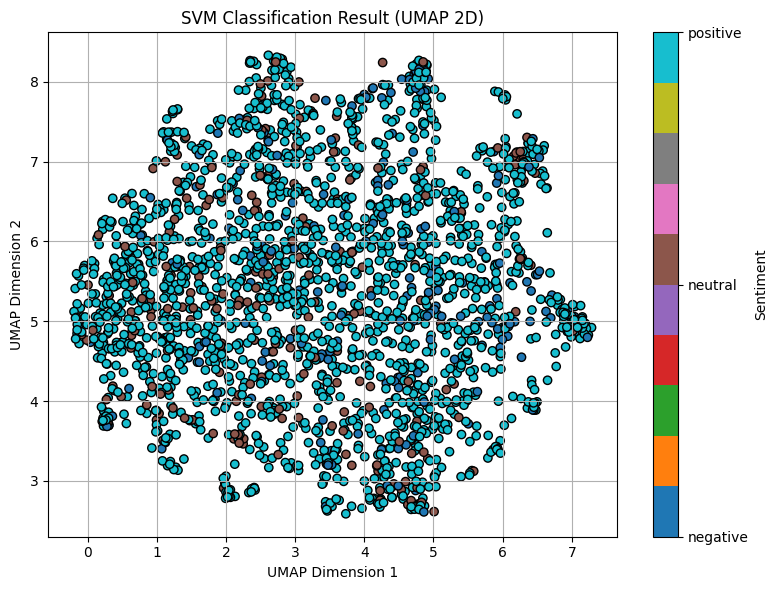

In [95]:
import umap.umap_ as umap
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_pred)

reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(X_test)  # หรือ FastText vector

# วาด scatter plot
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_umap[:, 0], X_umap[:, 1], c=y_encoded, cmap='tab10', edgecolors='k')
plt.title("SVM Classification Result (UMAP 2D)")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.grid(True)

# เพิ่มแถบสี
cbar = plt.colorbar(scatter, ticks=[0, 1, 2])
cbar.ax.set_yticklabels(label_encoder.classes_)
cbar.set_label("Sentiment")

plt.tight_layout()
plt.show()

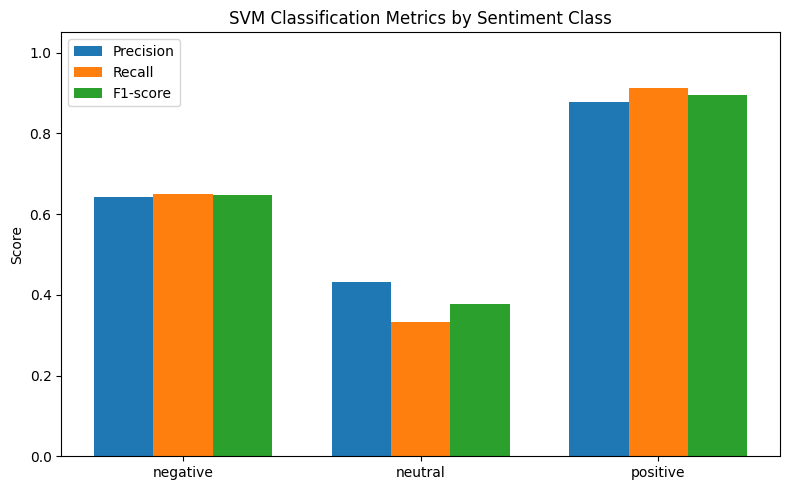

In [96]:
# สมมติว่า y_test, y_pred มีอยู่แล้ว
precisions = precision_score(y_test, y_pred, average=None, labels=['negative', 'neutral', 'positive'])
recalls = recall_score(y_test, y_pred, average=None, labels=['negative', 'neutral', 'positive'])
f1s = f1_score(y_test, y_pred, average=None, labels=['negative', 'neutral', 'positive'])

labels = ['negative', 'neutral', 'positive']
x = np.arange(len(labels))
width = 0.25

plt.figure(figsize=(8, 5))
plt.bar(x - width, precisions, width, label='Precision')
plt.bar(x, recalls, width, label='Recall')
plt.bar(x + width, f1s, width, label='F1-score')
plt.xticks(x, labels)
plt.ylim(0, 1.05)
plt.title('SVM Classification Metrics by Sentiment Class')
plt.ylabel('Score')
plt.legend()
plt.tight_layout()
plt.show()

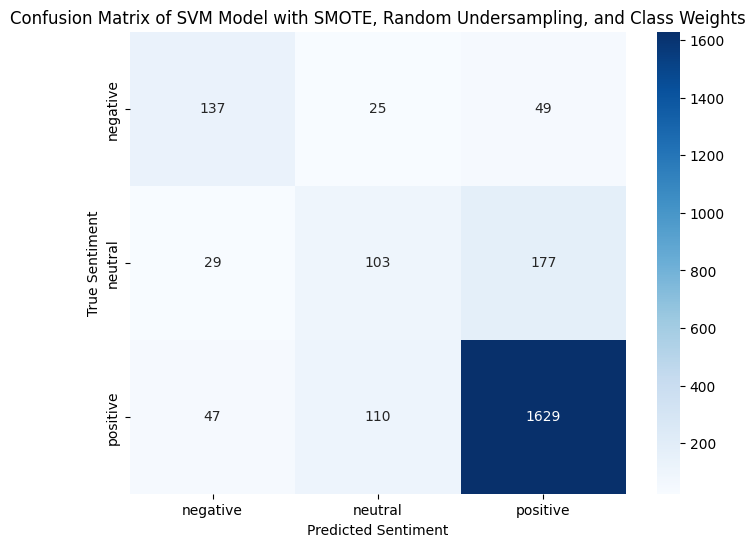

In [97]:
# Visualize the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['negative', 'neutral', 'positive'], yticklabels=['negative', 'neutral', 'positive'])
plt.xlabel('Predicted Sentiment')
plt.ylabel('True Sentiment')
plt.title('Confusion Matrix of SVM Model with SMOTE, Random Undersampling, and Class Weights')
plt.show()

In [48]:
y_pred

array(['neutral', 'neutral', 'positive', ..., 'neutral', 'positive',
       'positive'], dtype=object)

In [49]:
y_test

3489    negative
4909    positive
1425    positive
4743     neutral
439     positive
          ...   
5333    positive
4310    positive
653     positive
429      neutral
1773    positive
Name: sentiment, Length: 1182, dtype: object

In [99]:

predictions_df = pd.DataFrame({
    # "place_id": review_df.loc[y_test.index, 'place_id'],
    # "location_id": review_df.loc[y_test.index, 'location_id'],
    'review_text': review_df.loc[y_test.index, 'review_text'],  # Assuming X_test is a subset with a specific index
    'actual_sentiment': y_test,  # The actual sentiment labels
    'predicted_sentiment': y_pred  # The predicted sentiment labels
})

predictions_df.head(10)


,review_text,actual_sentiment,predicted_sentiment
6839,I am not a Buddhist but sympathetic to Buddhis...,positive,positive
6854,Enjoyed a very pleasant cycle along the river ...,positive,positive
6302,Not too far from Clock town and next to Night ...,positive,positive
10820,Catch a boat down the canal for only 19 baht t...,neutral,positive
9940,"As it's already been mentioned, this is a scam...",negative,negative
5930,The huge place contains ancient Khmer temple r...,positive,positive
6569,Beautiful and tranquil little spot. Bring wate...,neutral,positive
1512,Nice temple shaped as a ship. If you are lucky...,positive,positive
932,It's fairly typical resort (I'm using the Thai...,neutral,neutral
7584,This very small and less visited temple was us...,positive,positive


In [100]:
predictions_df.to_parquet('../test/predictions_SVM_EN_text_sentiment.parquet', engine='pyarrow', compression='zstd', index=False)